# Bloco 1 - Leitura dos dados Tratados

In [1]:
# ============================================================
# BLOCO 1 — Leitura e inspeção inicial da base tratada
# Objetivo:
# - Carregar a base analítica consolidada
# - Verificar dimensão, estrutura e tipos das variáveis
# - Iniciar o pipeline da Árvore de Decisão sem variáveis fuzzy
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Leitura da base tratada
df_tratado = pd.read_csv("base_tratada_aviacao.csv", sep=",")

# Dimensão da base
print("Dimensão da base tratada:", df_tratado.shape)

# Estrutura das variáveis
df_tratado.info()

C:\Users\FelipePedrosodeLimaB\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Dimensão da base tratada: (34939, 65)
<class 'pandas.DataFrame'>
RangeIndex: 34939 entries, 0 to 34938
Data columns (total 65 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       34939 non-null  int64  
 1   codigo_ocorrencia                34939 non-null  int64  
 2   codigo_ocorrencia1               34939 non-null  int64  
 3   codigo_ocorrencia2               34939 non-null  int64  
 4   codigo_ocorrencia3               34939 non-null  int64  
 5   codigo_ocorrencia4               34939 non-null  int64  
 6   ocorrencia_classificacao         34939 non-null  str    
 7   ocorrencia_latitude              34939 non-null  str    
 8   ocorrencia_longitude             34939 non-null  str    
 9   ocorrencia_cidade                34939 non-null  str    
 10  ocorrencia_uf                    34939 non-null  str    
 11  ocorrencia_pais                  34939 non-null  str 

# BLOCO 2 — Limpeza e preparação da base

In [3]:
# ============================================================
# BLOCO 2 — Limpeza de variáveis e prevenção de leakage
# Objetivo:
# - Remover variáveis que podem causar data leakage
# - Eliminar identificadores (IDs) sem valor preditivo
# - Excluir variáveis textuais de alta cardinalidade
# - Remover datas brutas sem tratamento
# - Manter apenas variáveis relevantes para modelagem
# ============================================================

# Lista de colunas a serem removidas
colunas_remover = [

    # 🔴 Variável derivada do target (risco de data leakage)
    "gravidade_fuzzy",

    # 🔴 Identificadores (IDs) — não agregam valor preditivo
    "Unnamed: 0",
    "codigo_ocorrencia",
    "codigo_ocorrencia1",
    "codigo_ocorrencia2",
    "codigo_ocorrencia3",
    "codigo_ocorrencia4",

    # 🔴 Variáveis textuais (alta cardinalidade / não estruturadas)
    "recomendacao_conteudo",
    "divulgacao_relatorio_numero",

    # 🔴 Datas brutas (não tratadas como features)
    "ocorrencia_dia",
    "ocorrencia_hora",
    "divulgacao_dia_publicacao",

    # ⚠️ Redundante com outra variável mais simples
    "ocorrencia_tipo_categoria"
]

# Aplicando remoção
df_modelo = df_tratado.drop(columns=colunas_remover, errors="ignore")

# Verificação da nova dimensão
print("Dimensão após limpeza:", df_modelo.shape)

# Visualização das colunas restantes
print("\nColunas disponíveis para modelagem:")
print(df_modelo.columns.tolist())

Dimensão após limpeza: (34939, 52)

Colunas disponíveis para modelagem:
['ocorrencia_classificacao', 'ocorrencia_latitude', 'ocorrencia_longitude', 'ocorrencia_cidade', 'ocorrencia_uf', 'ocorrencia_pais', 'ocorrencia_aerodromo', 'investigacao_aeronave_liberada', 'investigacao_status', 'divulgacao_relatorio_publicado', 'total_recomendacoes', 'total_aeronaves_envolvidas', 'ocorrencia_saida_pista', 'aeronave_matricula', 'aeronave_operador_categoria', 'aeronave_tipo_veiculo', 'aeronave_fabricante', 'aeronave_modelo', 'aeronave_tipo_icao', 'aeronave_motor_tipo', 'aeronave_motor_quantidade', 'aeronave_pmd', 'aeronave_pmd_categoria', 'aeronave_assentos', 'aeronave_ano_fabricacao', 'aeronave_pais_fabricante', 'aeronave_pais_registro', 'aeronave_registro_categoria', 'aeronave_registro_segmento', 'aeronave_voo_origem', 'aeronave_voo_destino', 'aeronave_fase_operacao', 'aeronave_tipo_operacao', 'aeronave_nivel_dano', 'aeronave_fatalidades_total', 'fator_nome', 'fator_aspecto', 'fator_condicionant

# BLOCO 3 — Salvando base limpa

In [ ]:
# ============================================================
# BLOCO 3 — Salvamento da base limpa para reutilização
# Objetivo:
# - Criar uma versão padronizada da base para todos os modelos
# - Garantir reprodutibilidade e consistência experimental
# ============================================================

df_modelo.to_csv("base_modelagem_aviacao.csv", index=False)

print("Base de modelagem salva com sucesso!")

# BLOCO 4 — Definição de X e y

In [4]:
# ============================================================
# BLOCO 4 — Definição de X e y
# Objetivo:
# - Definir o target oficial do estudo
# - Selecionar variáveis explicativas interpretáveis
# - Separar variáveis numéricas e categóricas
# ============================================================

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Target oficial do estudo
target = "ocorrencia_classificacao"

# Variáveis explicativas selecionadas
features = [
    "aeronave_fatalidades_total",
    "aeronave_assentos",
    "aeronave_nivel_dano",
    "total_recomendacoes",
    "fator_nome",
    "fator_area",
    "aeronave_pmd",
    "aeronave_tipo_operacao",
    "aeronave_tipo_veiculo",
    "ocorrencia_tipo"
]

X = df_modelo[features].copy()
y = df_modelo[target].copy()

# Separação das variáveis por tipo
variaveis_numericas = [
    "aeronave_fatalidades_total",
    "aeronave_assentos",
    "total_recomendacoes",
    "aeronave_pmd"
]

variaveis_categoricas = [
    "aeronave_nivel_dano",
    "fator_nome",
    "fator_area",
    "aeronave_tipo_operacao",
    "aeronave_tipo_veiculo",
    "ocorrencia_tipo"
]

print("Shape X:", X.shape)
print("Distribuição do target:")
print(y.value_counts(normalize=True).round(3))

Shape X: (34939, 10)
Distribuição do target:
ocorrencia_classificacao
ACIDENTE           0.605
INCIDENTE          0.276
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64


# BLOCO 5 — Separação treino/teste

In [5]:
# ============================================================
# BLOCO 5 — Separação treino/teste
# Objetivo:
# - Criar holdout estratificado
# - Preservar proporção das classes no treino e teste
# - Evitar vazamento de informação antes do pré-processamento
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Distribuição treino:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribuição teste:")
print(y_test.value_counts(normalize=True).round(3))

Distribuição treino:
ocorrencia_classificacao
ACIDENTE           0.605
INCIDENTE          0.276
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64

Distribuição teste:
ocorrencia_classificacao
ACIDENTE           0.605
INCIDENTE          0.276
INCIDENTE GRAVE    0.119
Name: proportion, dtype: float64


# BLOCO 6 — Pipeline de pré-processamento + Árvore de Decisão

In [6]:
# ============================================================
# BLOCO 6 — Pipeline de pré-processamento + Árvore de Decisão
# Objetivo:
# - Tratar valores ausentes sem data leakage
# - Aplicar One-Hot Encoding nas variáveis categóricas
# - Manter variáveis numéricas no pipeline
# - Treinar Árvore de Decisão como baseline
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer

# Pipeline para variáveis numéricas:
# - Preenche valores ausentes com a mediana do conjunto de treino
pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Pipeline para variáveis categóricas:
# - Preenche valores ausentes com "NÃO INFORMADO"
# - Aplica One-Hot Encoding
pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="NÃO INFORMADO")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Pré-processador completo
preprocessador = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, variaveis_numericas),
        ("cat", pipeline_categorico, variaveis_categoricas)
    ]
)

# Pipeline final
pipeline_arvore = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", DecisionTreeClassifier(random_state=42))
    ]
)

print("Pipeline com imputação criado com sucesso!")

Pipeline com imputação criado com sucesso!


# BLOCO 7 — Grid Search com validação cruzada

In [8]:
# ============================================================
# BLOCO 7 — Grid Search com validação cruzada
# Objetivo:
# - Ajustar hiperparâmetros da árvore
# - Usar validação cruzada estratificada
# - Avaliar o modelo com maior rigor experimental
# - Registrar tempo de execução
# ============================================================

from datetime import datetime
import time

param_grid = {
    "modelo__max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20],
    "modelo__min_samples_leaf": [1, 2, 4, 8],
    "modelo__criterion": ["gini", "entropy"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=pipeline_arvore,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

inicio_grid = datetime.now()
inicio_perf = time.perf_counter()

print("Início do Grid Search:", inicio_grid.strftime("%Y-%m-%d %H:%M:%S"))

grid_search.fit(X_train, y_train)

fim_grid = datetime.now()
fim_perf = time.perf_counter()

tempo_total_segundos = fim_perf - inicio_perf
tempo_total_minutos = tempo_total_segundos / 60

melhor_modelo_arvore = grid_search.best_estimator_

print("\nFim do Grid Search:", fim_grid.strftime("%Y-%m-%d %H:%M:%S"))

print("\nTempo total do Grid Search:")
print(f"{tempo_total_segundos:.2f} segundos")
print(f"{tempo_total_minutos:.2f} minutos")

print("\nMelhores parâmetros:")
print(grid_search.best_params_)

print("\nMelhor F1-macro médio na validação cruzada:")
print(round(grid_search.best_score_, 4))

Início do Grid Search: 2026-05-31 13:23:34

Fim do Grid Search: 2026-05-31 13:28:12

Tempo total do Grid Search:
278.78 segundos
4.65 minutos

Melhores parâmetros:
{'modelo__criterion': 'entropy', 'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 10}

Melhor F1-macro médio na validação cruzada:
0.9235


# BLOCO 8 — Avaliação no conjunto de teste

Classification Report — Árvore de Decisão (Teste):

                 precision    recall  f1-score   support

       ACIDENTE       0.98      0.99      0.99      6339
      INCIDENTE       0.95      0.97      0.96      2894
INCIDENTE GRAVE       0.89      0.83      0.86      1249

       accuracy                           0.96     10482
      macro avg       0.94      0.93      0.93     10482
   weighted avg       0.96      0.96      0.96     10482



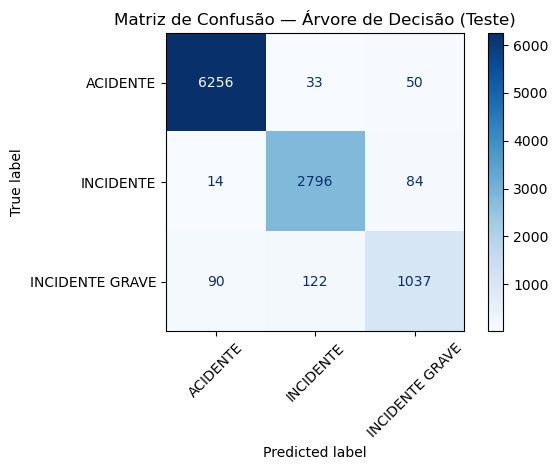

In [9]:
# ============================================================
# BLOCO 8 — Avaliação final no conjunto de teste
# Objetivo:
# - Avaliar o modelo em dados não vistos (holdout)
# - Gerar métricas por classe (precision, recall, f1-score)
# - Identificar impacto do desbalanceamento
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred = melhor_modelo_arvore.predict(X_test)

# Relatório de classificação
print("Classification Report — Árvore de Decisão (Teste):\n")
print(classification_report(y_test, y_pred))

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred, labels=melhor_modelo_arvore.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=melhor_modelo_arvore.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão — Árvore de Decisão (Teste)")
plt.tight_layout()
plt.show()

# BLOCO 9 — Visualização da árvore final otimizada

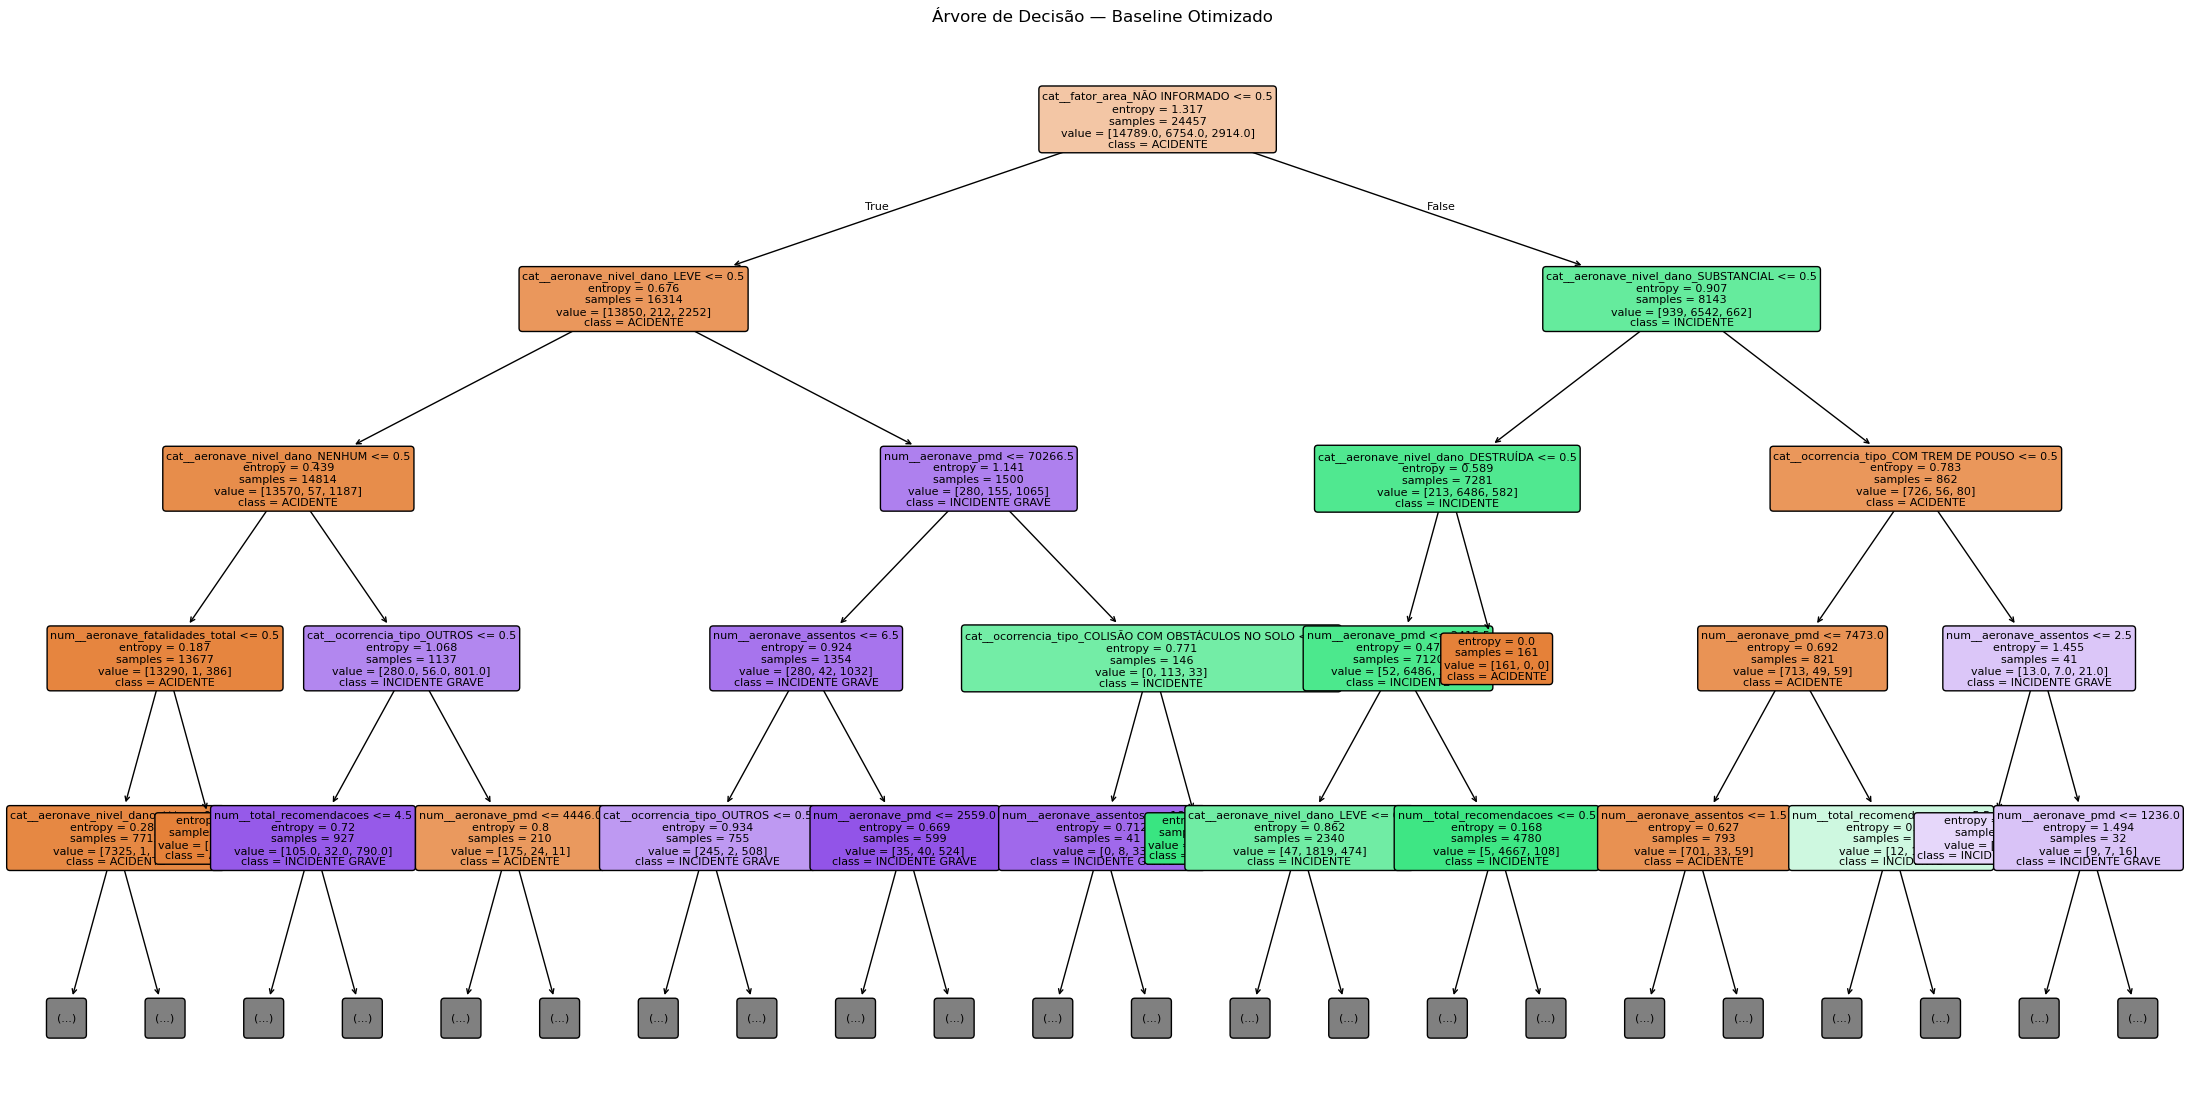

In [10]:
# ============================================================
# BLOCO 9 — Visualização da árvore final otimizada
# Objetivo:
# - Visualizar a estrutura da Árvore de Decisão final
# - Apoiar a análise de interpretabilidade do baseline
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

modelo_final_arvore = melhor_modelo_arvore.named_steps["modelo"]
preprocessador_final = melhor_modelo_arvore.named_steps["preprocessamento"]

feature_names = preprocessador_final.get_feature_names_out()

plt.figure(figsize=(28, 14))

plot_tree(
    modelo_final_arvore,
    feature_names=feature_names,
    class_names=melhor_modelo_arvore.classes_,
    filled=True,
    rounded=True,
    max_depth=4,  # limita visualmente para não ficar ilegível
    fontsize=8
)

plt.title("Árvore de Decisão — Baseline Otimizado")
plt.show()

# BLOCO 10 — Extração das regras da árvore final

In [11]:
# ============================================================
# BLOCO 10 — Extração das regras da árvore final
# Objetivo:
# - Extrair regras textuais interpretáveis
# - Apoiar a comparação entre regras crisp e regras fuzzy
# ============================================================

from sklearn.tree import export_text

regras_arvore = export_text(
    modelo_final_arvore,
    feature_names=list(feature_names),
    decimals=2,
    max_depth=5
)

print(regras_arvore)

|--- cat__fator_area_NÃO INFORMADO <= 0.50
|   |--- cat__aeronave_nivel_dano_LEVE <= 0.50
|   |   |--- cat__aeronave_nivel_dano_NENHUM <= 0.50
|   |   |   |--- num__aeronave_fatalidades_total <= 0.50
|   |   |   |   |--- cat__aeronave_nivel_dano_*** <= 0.50
|   |   |   |   |   |--- num__total_recomendacoes <= 3.50
|   |   |   |   |   |   |--- truncated branch of depth 22
|   |   |   |   |   |--- num__total_recomendacoes >  3.50
|   |   |   |   |   |   |--- truncated branch of depth 8
|   |   |   |   |--- cat__aeronave_nivel_dano_*** >  0.50
|   |   |   |   |   |--- num__aeronave_assentos <= 4.50
|   |   |   |   |   |   |--- class: ACIDENTE
|   |   |   |   |   |--- num__aeronave_assentos >  4.50
|   |   |   |   |   |   |--- class: INCIDENTE GRAVE
|   |   |   |--- num__aeronave_fatalidades_total >  0.50
|   |   |   |   |--- class: ACIDENTE
|   |   |--- cat__aeronave_nivel_dano_NENHUM >  0.50
|   |   |   |--- cat__ocorrencia_tipo_OUTROS <= 0.50
|   |   |   |   |--- num__total_recomendacoe

# BLOCO 11 — Árvore de Decisão com balanceamento por class_weight

In [12]:
# ============================================================
# BLOCO 11 — Árvore de Decisão com balanceamento por class_weight
# Objetivo:
# - Avaliar o impacto do desbalanceamento de classes
# - Preservar todos os dados originais
# - Atribuir maior peso às classes minoritárias durante o treino
# - Comparar com o baseline desbalanceado
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline da árvore balanceada
pipeline_arvore_balanceada = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", DecisionTreeClassifier(
            random_state=42,
            class_weight="balanced"
        ))
    ]
)

# Grid de hiperparâmetros
param_grid_balanceado = {
    "modelo__max_depth": [3, 4, 5, 6, 7, 8, 10, None],
    "modelo__min_samples_split": [2, 5, 10, 20],
    "modelo__min_samples_leaf": [1, 2, 4, 8],
    "modelo__criterion": ["gini", "entropy"]
}

# Grid Search com validação cruzada estratificada
grid_search_balanceado = GridSearchCV(
    estimator=pipeline_arvore_balanceada,
    param_grid=param_grid_balanceado,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    return_train_score=True
)

# Treinamento
grid_search_balanceado.fit(X_train, y_train)

# Melhor modelo balanceado
melhor_modelo_arvore_balanceada = grid_search_balanceado.best_estimator_

print("Melhores parâmetros — Árvore Balanceada:")
print(grid_search_balanceado.best_params_)

print("\nMelhor F1-macro médio na validação cruzada — Árvore Balanceada:")
print(round(grid_search_balanceado.best_score_, 4))

Melhores parâmetros — Árvore Balanceada:
{'modelo__criterion': 'entropy', 'modelo__max_depth': None, 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 2}

Melhor F1-macro médio na validação cruzada — Árvore Balanceada:
0.9183


# BLOCO 12 — avaliação no teste

Classification Report — Árvore de Decisão Balanceada (Teste):

                 precision    recall  f1-score   support

       ACIDENTE       0.99      0.98      0.98      6339
      INCIDENTE       0.96      0.94      0.95      2894
INCIDENTE GRAVE       0.82      0.87      0.84      1249

       accuracy                           0.96     10482
      macro avg       0.92      0.93      0.93     10482
   weighted avg       0.96      0.96      0.96     10482



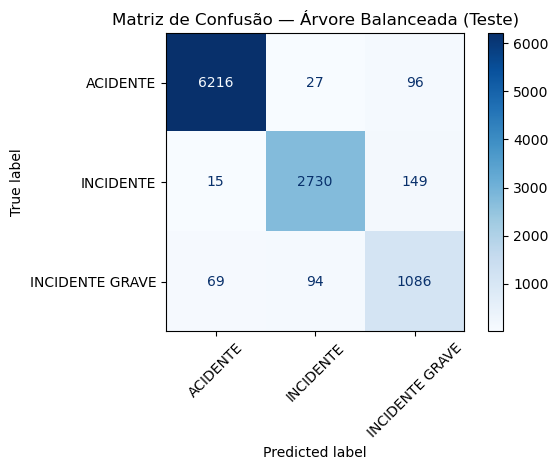

In [13]:
# ============================================================
# BLOCO 12 — Avaliação da Árvore Balanceada no conjunto de teste
# Objetivo:
# - Avaliar o modelo balanceado em dados não vistos (holdout)
# - Comparar desempenho com o baseline desbalanceado
# - Analisar impacto na classe minoritária (INCIDENTE GRAVE)
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred_balanceado = melhor_modelo_arvore_balanceada.predict(X_test)

# Relatório de classificação
print("Classification Report — Árvore de Decisão Balanceada (Teste):\n")
print(classification_report(y_test, y_pred_balanceado))

# Matriz de confusão
cm_balanceado = confusion_matrix(
    y_test,
    y_pred_balanceado,
    labels=melhor_modelo_arvore_balanceada.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanceado,
    display_labels=melhor_modelo_arvore_balanceada.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusão — Árvore Balanceada (Teste)")
plt.tight_layout()
plt.show()

# BLOCO 13 — Árvore Interpretável com Profundidade Controlada

In [14]:
# ============================================================
# BLOCO 13 — Árvore Interpretável com Profundidade Controlada
# Objetivo:
# - Treinar uma árvore mais simples para fins de interpretação
# - Facilitar comparação com regras fuzzy
# - Permitir ajuste rápido da profundidade da árvore
# ============================================================

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Parâmetro principal de interpretabilidade
PROFUNDIDADE_ARVORE_INTERPRETAVEL = 3  # altere para 2, 3, 4, 5...

pipeline_arvore_interpretavel = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", DecisionTreeClassifier(
            max_depth=PROFUNDIDADE_ARVORE_INTERPRETAVEL,
            min_samples_split=10,
            min_samples_leaf=5,
            criterion="entropy",
            random_state=42
        ))
    ]
)

pipeline_arvore_interpretavel.fit(X_train, y_train)

print("Árvore interpretável treinada com sucesso!")
print("Profundidade utilizada:", PROFUNDIDADE_ARVORE_INTERPRETAVEL)

Árvore interpretável treinada com sucesso!
Profundidade utilizada: 3


# BLOCO 14 — Plot da Árvore Interpretável

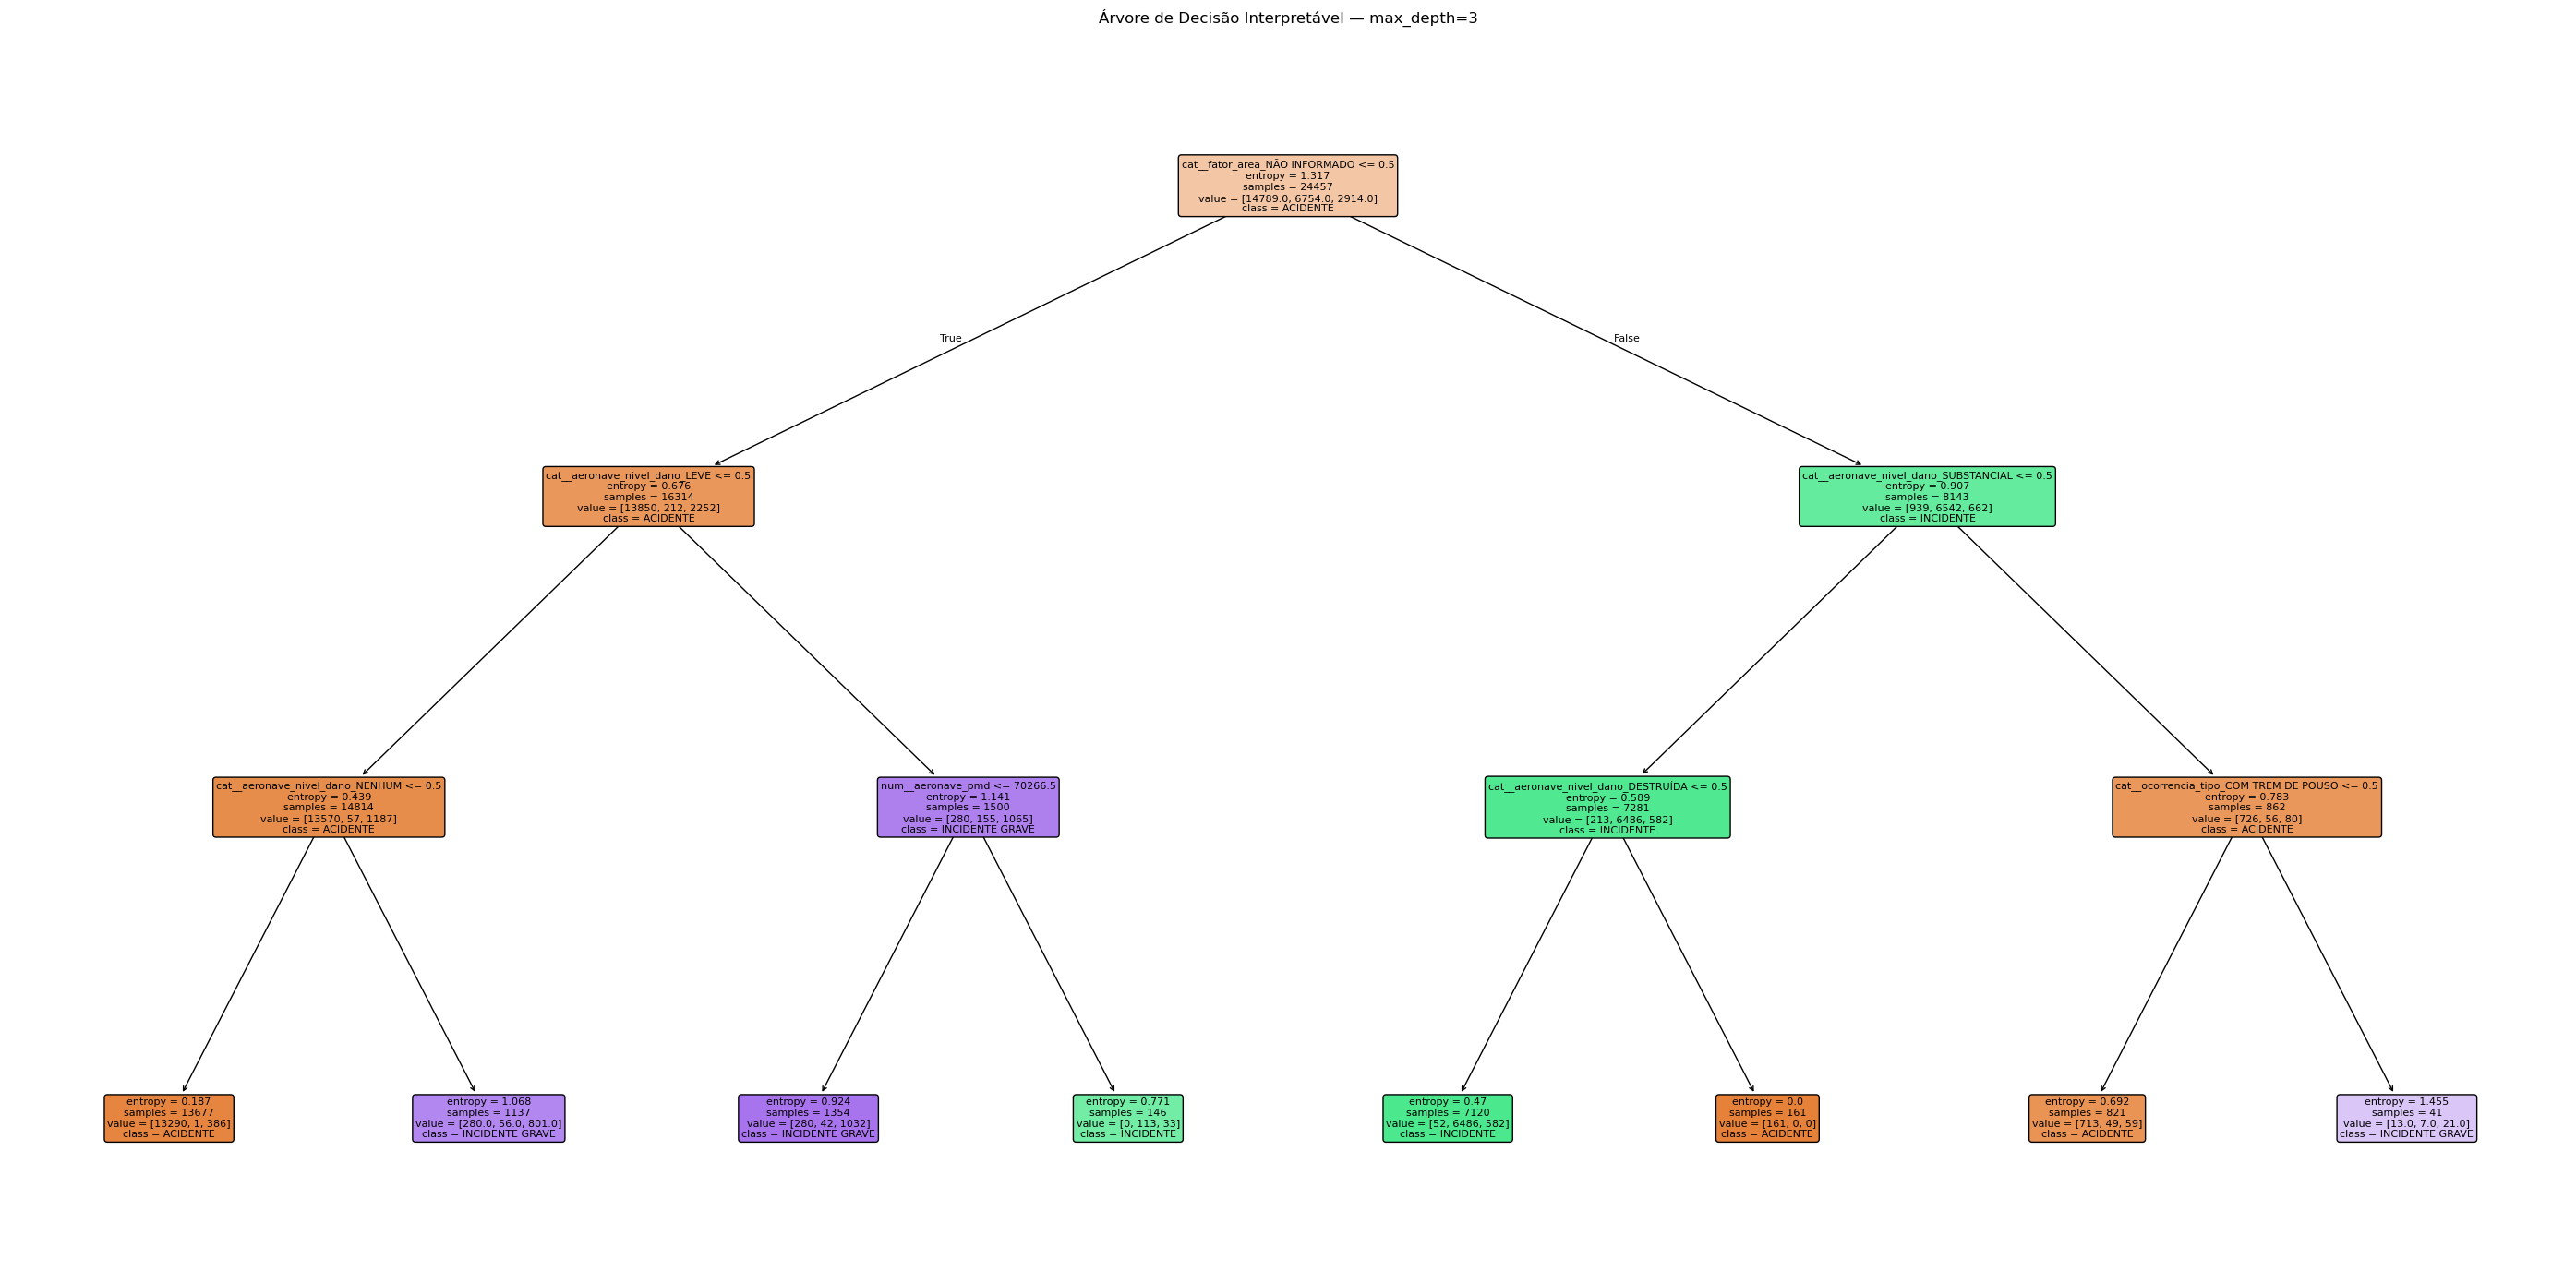

In [15]:
# ============================================================
# BLOCO 14 — Plot da Árvore Interpretável
# Objetivo:
# - Visualizar regras crisp aprendidas pela árvore
# - Apoiar discussão de interpretabilidade no paper
# ============================================================

modelo_interpretavel = pipeline_arvore_interpretavel.named_steps["modelo"]
preprocessador_interpretavel = pipeline_arvore_interpretavel.named_steps["preprocessamento"]

feature_names_interpretavel = preprocessador_interpretavel.get_feature_names_out()

plt.figure(figsize=(28, 14))

plot_tree(
    modelo_interpretavel,
    feature_names=feature_names_interpretavel,
    class_names=pipeline_arvore_interpretavel.classes_,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    f"Árvore de Decisão Interpretável — max_depth={PROFUNDIDADE_ARVORE_INTERPRETAVEL}"
)
plt.tight_layout()
plt.show()

# BLOCO 15 — Extração das Regras da Árvore Interpretável

In [16]:
# ============================================================
# BLOCO 15 — Extração das Regras da Árvore Interpretável
# Objetivo:
# - Extrair regras textuais para comparação com regras fuzzy
# - Apoiar análise qualitativa entre regras crisp e fuzzy
# ============================================================

regras_arvore_interpretavel = export_text(
    modelo_interpretavel,
    feature_names=list(feature_names_interpretavel),
    decimals=2
)

print("Regras da Árvore Interpretável:\n")
print(regras_arvore_interpretavel)

Regras da Árvore Interpretável:

|--- cat__fator_area_NÃO INFORMADO <= 0.50
|   |--- cat__aeronave_nivel_dano_LEVE <= 0.50
|   |   |--- cat__aeronave_nivel_dano_NENHUM <= 0.50
|   |   |   |--- class: ACIDENTE
|   |   |--- cat__aeronave_nivel_dano_NENHUM >  0.50
|   |   |   |--- class: INCIDENTE GRAVE
|   |--- cat__aeronave_nivel_dano_LEVE >  0.50
|   |   |--- num__aeronave_pmd <= 70266.50
|   |   |   |--- class: INCIDENTE GRAVE
|   |   |--- num__aeronave_pmd >  70266.50
|   |   |   |--- class: INCIDENTE
|--- cat__fator_area_NÃO INFORMADO >  0.50
|   |--- cat__aeronave_nivel_dano_SUBSTANCIAL <= 0.50
|   |   |--- cat__aeronave_nivel_dano_DESTRUÍDA <= 0.50
|   |   |   |--- class: INCIDENTE
|   |   |--- cat__aeronave_nivel_dano_DESTRUÍDA >  0.50
|   |   |   |--- class: ACIDENTE
|   |--- cat__aeronave_nivel_dano_SUBSTANCIAL >  0.50
|   |   |--- cat__ocorrencia_tipo_COM TREM DE POUSO <= 0.50
|   |   |   |--- class: ACIDENTE
|   |   |--- cat__ocorrencia_tipo_COM TREM DE POUSO >  0.50
|   |   

# BLOCO 16 — Avaliação da Árvore Interpretável

Classification Report — Árvore Interpretável (Teste):

                 precision    recall  f1-score   support

       ACIDENTE       0.97      0.95      0.96      6339
      INCIDENTE       0.90      0.98      0.94      2894
INCIDENTE GRAVE       0.73      0.65      0.69      1249

       accuracy                           0.92     10482
      macro avg       0.87      0.86      0.86     10482
   weighted avg       0.92      0.92      0.92     10482



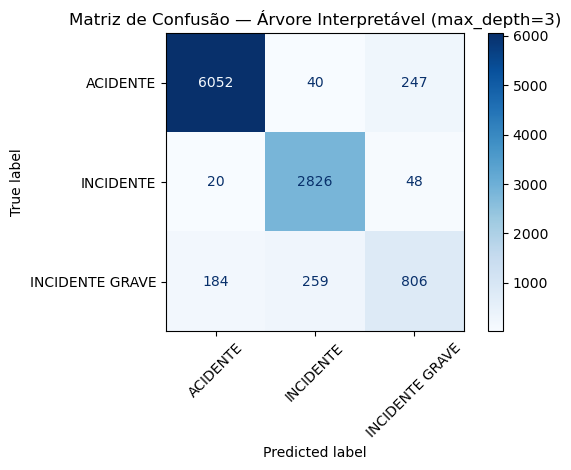

In [17]:
# ============================================================
# BLOCO 16 — Avaliação da Árvore Interpretável
# Objetivo:
# - Avaliar a árvore simplificada no conjunto de teste
# - Comparar desempenho com os modelos otimizados
# - Medir o custo de simplificar a árvore para interpretabilidade
# ============================================================

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Previsões no conjunto de teste
y_pred_interpretavel = pipeline_arvore_interpretavel.predict(X_test)

# Relatório de classificação
print("Classification Report — Árvore Interpretável (Teste):\n")
print(classification_report(y_test, y_pred_interpretavel))

# Matriz de confusão
cm_interpretavel = confusion_matrix(
    y_test,
    y_pred_interpretavel,
    labels=pipeline_arvore_interpretavel.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_interpretavel,
    display_labels=pipeline_arvore_interpretavel.classes_
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title(
    f"Matriz de Confusão — Árvore Interpretável "
    f"(max_depth={PROFUNDIDADE_ARVORE_INTERPRETAVEL})"
)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.tree import _tree

def extrair_regras_pipeline(pipeline, simplificar=True):
    modelo = pipeline.named_steps["modelo"]
    preprocessador = pipeline.named_steps["preprocessamento"]
    
    feature_names = preprocessador.get_feature_names_out()
    class_names = pipeline.classes_
    
    tree_ = modelo.tree_
    
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
        for i in tree_.feature
    ]
    
    regras = []
    
    def limpar_nome(nome):
        # remove prefixos do pipeline (cat__, num__)
        nome = nome.replace("cat__", "").replace("num__", "")
        
        # opcional: melhorar leitura
        nome = nome.replace("_", " ")
        
        return nome

    def traduzir_condicao(nome_feat, operador, limiar):
        nome_feat_limpo = limpar_nome(nome_feat)
        
        # tratamento especial para one-hot encoding (categorias)
        if "<=" in operador:
            return f"{nome_feat_limpo} = NÃO"
        else:
            return f"{nome_feat_limpo} = SIM"
    
    def recurse(node, caminho):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            nome_feat = feature_name[node]
            limiar = tree_.threshold[node]
            
            # esquerda (<=)
            cond_esq = f"{limpar_nome(nome_feat)} <= {limiar:.2f}"
            recurse(tree_.children_left[node], caminho + [cond_esq])
            
            # direita (>)
            cond_dir = f"{limpar_nome(nome_feat)} > {limiar:.2f}"
            recurse(tree_.children_right[node], caminho + [cond_dir])
        
        else:
            classe = class_names[tree_.value[node].argmax()]
            
            regra = "SE " + " E ".join(caminho) + f" → {classe}"
            regras.append(regra)
    
    recurse(0, [])
    return regras


In [19]:
regras = extrair_regras_pipeline(pipeline_arvore_interpretavel)

for i, r in enumerate(regras, 1):
    print(f"Regra {i}:")
    print(r)
    print("-"*80)


Regra 1:
SE fator area NÃO INFORMADO <= 0.50 E aeronave nivel dano LEVE <= 0.50 E aeronave nivel dano NENHUM <= 0.50 → ACIDENTE
--------------------------------------------------------------------------------
Regra 2:
SE fator area NÃO INFORMADO <= 0.50 E aeronave nivel dano LEVE <= 0.50 E aeronave nivel dano NENHUM > 0.50 → INCIDENTE GRAVE
--------------------------------------------------------------------------------
Regra 3:
SE fator area NÃO INFORMADO <= 0.50 E aeronave nivel dano LEVE > 0.50 E aeronave pmd <= 70266.50 → INCIDENTE GRAVE
--------------------------------------------------------------------------------
Regra 4:
SE fator area NÃO INFORMADO <= 0.50 E aeronave nivel dano LEVE > 0.50 E aeronave pmd > 70266.50 → INCIDENTE
--------------------------------------------------------------------------------
Regra 5:
SE fator area NÃO INFORMADO > 0.50 E aeronave nivel dano SUBSTANCIAL <= 0.50 E aeronave nivel dano DESTRUÍDA <= 0.50 → INCIDENTE
-----------------------------------